# Models — baseline temporal, GAM y CatBoost

Entrenamiento y comparación inicial de tres modelos para predecir `avg_duration_months`: un baseline estacional, un GAM interpretable y CatBoost como predictor principal. No utiliza AutoML ni Deep Learning.

La métrica está en **meses**, porque el objetivo del dataset es la duración simulada de un autocallable.

## Objetivo y alcance

- Cada fila representa una RFQ; no hay hora, campaña ni cola.
- El objetivo es `avg_duration_months`, disponible solo para RFQs ejecutadas.
- El notebook compara tres aproximaciones con un corte temporal: pasado para entrenar y futuro para evaluar.
- GAM y SHAP describen asociaciones predictivas, no causalidad.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import SplineTransformer

RANDOM_SEED = 42
TARGET = 'avg_duration_months'
HOLDOUT_DAYS = 180

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'data' / 'processed').exists() else cwd.parent
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'train_features.csv'
MODELS_DIR = PROJECT_ROOT / 'models'
BASELINE_DIR = MODELS_DIR / 'baseline'
GAM_DIR = MODELS_DIR / 'gam'
CATBOOST_DIR = MODELS_DIR / 'catboost'
REPORTS_DIR = MODELS_DIR / 'reports'
for directory in [BASELINE_DIR, GAM_DIR, CATBOOST_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Models directory: {MODELS_DIR}')

Project root: /home/kiril/Proyectos/starwars_autocalls
Models directory: /home/kiril/Proyectos/starwars_autocalls/models


## Carga y contrato de variables

`Preprocess_starwars.ipynb` ya hace el join de mercado con el último dato estrictamente anterior a `requested_date`; se usa su tabla procesada. Se vuelven a excluir las variables que no se conocen al cotizar: identificador, objetivo, resultado de ejecución y fechas de inicio/finalización.

La variable experimental `realized_vol_trend_21d_mean` resume si la volatilidad realizada de los subyacentes de la cesta estaba por encima o por debajo de su media de las 21 observaciones de mercado anteriores. Un valor positivo indica subida reciente; uno negativo, bajada reciente. Se conserva para experimentación, pero queda fuera del contrato principal porque no mejoró el MAE de CatBoost.

In [2]:
data = pd.read_csv(DATA_PATH, parse_dates=['requested_date', 'start_date', 'end_date'])

FORBIDDEN_COLUMNS = {
    'rfq_id', TARGET, 'executed', 'underlyings', 'observation_frequency',
    'requested_date', 'start_date', 'end_date',
}
EXPERIMENTAL_ONLY_COLUMNS = {'realized_vol_trend_21d_mean'}
feature_columns = [
    c for c in data.columns
    if c not in FORBIDDEN_COLUMNS and c not in EXPERIMENTAL_ONLY_COLUMNS
]

assert data[TARGET].notna().all(), 'El entrenamiento requiere objetivo observado.'
assert data['executed'].eq(True).all(), 'train_features debe contener solo RFQs ejecutadas.'
assert not (set(feature_columns) & FORBIDDEN_COLUMNS), 'Hay una variable prohibida en el modelo.'
assert data[feature_columns].select_dtypes(include='object').empty, 'Las variables deben ser numéricas.'
assert not data[feature_columns].isna().any().any(), 'Hay nulos en las variables de entrada.'

print(f'Filas: {len(data):,}')
print(f'Periodo: {data.requested_date.min():%Y-%m-%d} a {data.requested_date.max():%Y-%m-%d}')
print(f'Variables predictoras: {len(feature_columns)}')
print(f'Variables experimentales fuera del contrato principal: {sorted(EXPERIMENTAL_ONLY_COLUMNS)}')
display(data[[TARGET, 'requested_date']].describe())

Filas: 13,796
Periodo: 2016-01-04 a 2024-06-28
Variables predictoras: 96
Variables experimentales fuera del contrato principal: ['realized_vol_trend_21d_mean']


,avg_duration_months,requested_date
count,13796.000000,13796
mean,39.782783,2020-03-24 17:39:32.513772
min,0.160000,2016-01-04 00:00:00
25%,23.567500,2018-02-14 00:00:00
50%,35.380000,2020-03-24 12:00:00
75%,51.952500,2022-05-06 00:00:00
max,127.710000,2024-06-28 00:00:00
std,22.105132,NaN


## Corte temporal: pasado para entrenar, futuro para evaluar

El corte se determina solo por `requested_date`. No se mezclan RFQs futuras en el entrenamiento y no hay división aleatoria.

In [3]:
test_start = data['requested_date'].max().normalize() - pd.Timedelta(days=HOLDOUT_DAYS - 1)
train = data.loc[data['requested_date'] < test_start].copy()
test = data.loc[data['requested_date'] >= test_start].copy()

assert train['requested_date'].max() < test['requested_date'].min()
assert len(train) and len(test)

split_summary = pd.DataFrame({
    'split': ['train (pasado)', 'test (futuro reservado)'],
    'n_rfqs': [len(train), len(test)],
    'from': [train.requested_date.min().date(), test.requested_date.min().date()],
    'to': [train.requested_date.max().date(), test.requested_date.max().date()],
})
display(split_summary)

X_train, y_train = train[feature_columns], train[TARGET]
X_test, y_test = test[feature_columns], test[TARGET]

,split,n_rfqs,from,to
0,train (pasado),13050,2016-01-04,2023-12-29
1,test (futuro reservado),746,2024-01-01,2024-06-28


## Modelo 1 — baseline temporal estacional simple

Mediana histórica por mes y día de la semana. Si una combinación no aparece en pasado, usa la mediana del mes y después la mediana global. Solo emplea objetivos del conjunto de entrenamiento.

In [4]:
def add_calendar_parts(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame[['requested_date']].copy()
    result['month'] = result['requested_date'].dt.month
    result['day_of_week'] = result['requested_date'].dt.dayofweek
    return result

calendar_train = add_calendar_parts(train).assign(target=y_train.to_numpy())
seasonal_by_month_dow = calendar_train.groupby(['month', 'day_of_week'])['target'].median()
seasonal_by_month = calendar_train.groupby('month')['target'].median()
seasonal_global = float(y_train.median())

def predict_seasonal_baseline(frame: pd.DataFrame) -> np.ndarray:
    calendar = add_calendar_parts(frame)
    keys = pd.MultiIndex.from_frame(calendar[['month', 'day_of_week']])
    prediction = pd.Series(seasonal_by_month_dow.reindex(keys).to_numpy(), index=frame.index)
    prediction = prediction.fillna(calendar['month'].map(seasonal_by_month).set_axis(frame.index))
    return prediction.fillna(seasonal_global).to_numpy()

pred_baseline = predict_seasonal_baseline(test)
pd.concat([seasonal_by_month_dow.rename('median_duration_months')], axis=1).to_csv(
    BASELINE_DIR / 'seasonal_medians.csv'
)

## Modelo 2 — GAM explicativo

Se modelan efectos no lineales aditivos mediante splines para variables numéricas de negocio y términos lineales para las dummies de producto, cesta, contraparte, trader y subyacentes. No incorpora interacciones: es deliberadamente interpretable y complementa, no sustituye, al modelo predictivo principal.

In [5]:
gam_spline_columns = [
    'autocall_barrier_pct', 'protection_barrier_pct', 'no_call_period_months',
    'observation_frequency_months', 'quoted_implied_vol', 'log_notional_credits',
    'basket_size', 'realized_vol_mean', 'realized_vol_range',
    'structural_base_vol_mean', 'structural_base_vol_range', 'market_lag_days_max',
    'requested_month_sin', 'requested_month_cos', 'requested_dayofweek',
]
gam_spline_columns = [c for c in gam_spline_columns if c in feature_columns]
gam_linear_columns = [c for c in feature_columns if c not in gam_spline_columns and c != 'requested_year']

gam_preprocessor = ColumnTransformer(
    transformers=[
        ('spline', SplineTransformer(n_knots=5, degree=3, extrapolation='linear'), gam_spline_columns),
        ('linear', 'passthrough', gam_linear_columns),
    ],
    remainder='drop',
)
gam = Pipeline([
    ('features', gam_preprocessor),
    ('regressor', Ridge(alpha=10.0)),
])
gam.fit(X_train, y_train)
pred_gam = gam.predict(X_test)
joblib.dump(gam, GAM_DIR / 'model.joblib')

print(f'Splines: {len(gam_spline_columns)} | Términos lineales: {len(gam_linear_columns)}')

Splines: 15 | Términos lineales: 80


/home/kiril/Proyectos/starwars_autocalls/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2169758564865308e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


## Modelo 3 — CatBoost, predictor principal

CatBoost usa las mismas variables conocidas al cotizar. La configuración es fija y deliberadamente pequeña; no hay búsqueda automática de hiperparámetros.

In [6]:
catboost = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    iterations=800,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=5.0,
    random_seed=RANDOM_SEED,
    verbose=False,
    allow_writing_files=False,
)
catboost.fit(X_train, y_train)
pred_catboost = catboost.predict(X_test)
catboost.save_model(str(CATBOOST_DIR / 'model.cbm'))

## Comparación en el futuro reservado

MAE es la métrica principal y RMSE la secundaria. Ambas se calculan únicamente sobre RFQs posteriores al corte temporal.

In [7]:
predictions = {
    'Baseline estacional (mes × día semana)': pred_baseline,
    'GAM explicativo': pred_gam,
    'CatBoost principal': pred_catboost,
}
metrics = pd.DataFrame([
    {
        'model': name,
        'MAE_months': mean_absolute_error(y_test, pred),
        'RMSE_months': root_mean_squared_error(y_test, pred),
    }
    for name, pred in predictions.items()
]).sort_values('MAE_months').reset_index(drop=True)

metrics.to_csv(REPORTS_DIR / 'holdout_metrics.csv', index=False)
display(metrics.style.format({'MAE_months': '{:.3f}', 'RMSE_months': '{:.3f}'}))

best_model = metrics.iloc[0]['model']
print(f'Mejor MAE futuro: {best_model}')
summary = f"""# Resultados de modelos


Holdout temporal: {test.requested_date.min():%Y-%m-%d} a {test.requested_date.max():%Y-%m-%d} ({len(test):,} RFQs).

| Modelo | MAE (meses) | RMSE (meses) |
|---|---:|---:|
"""
summary += '\n'.join(
    f"| {row.model} | {row.MAE_months:.3f} | {row.RMSE_months:.3f} |"
    for row in metrics.itertuples(index=False)
)
summary += '\n\nCatBoost es el modelo predictivo principal en esta primera comparación. El GAM se conserva para interpretación y el baseline es la referencia mínima.\n'
(MODELS_DIR / 'README.md').write_text(summary, encoding='utf-8')


,model,MAE_months,RMSE_months
0,CatBoost principal,11.269,15.366
1,GAM explicativo,12.596,16.035
2,Baseline estacional (mes × día semana),18.135,22.320


Mejor MAE futuro: CatBoost principal


428

## Interpretabilidad: asociaciones, no causalidad

Para el GAM se exportan los coeficientes lineales. Para CatBoost se calcula una tabla de importancia SHAP media absoluta en el futuro reservado. Estas señales indican qué variables usa el modelo para predecir, no el efecto causal de una intervención.

,term,coefficient,abs_coefficient
120,linear__has_underlying_HTTX,23.967903,23.967903
111,linear__structural_base_vol_min,-17.758165,17.758165
126,linear__has_underlying_REBL,-16.752378,16.752378
112,linear__structural_base_vol_max,-14.190255,14.190255
108,linear__realized_vol_min,-13.514640,13.514640
124,linear__has_underlying_NABO,-12.546276,12.546276
135,linear__product_type_Wretched Hive Digital,9.107207,9.107207
114,linear__realized_minus_structural_vol,8.544394,8.544394
121,linear__has_underlying_JEDI,-7.898645,7.898645
125,linear__has_underlying_POBK,7.883406,7.883406


,feature,mean_abs_shap_months
5,observation_frequency_months,3.441480
0,autocall_barrier_pct,2.858312
1,protection_barrier_pct,2.354878
37,has_underlying_REBL,2.043330
14,realized_vol_min,1.655791
46,product_type_Wretched Hive Digital,1.644118
31,has_underlying_HTTX,1.173658
13,n_market_matches,1.091107
19,structural_base_vol_max,0.984555
12,n_underlyings,0.980487


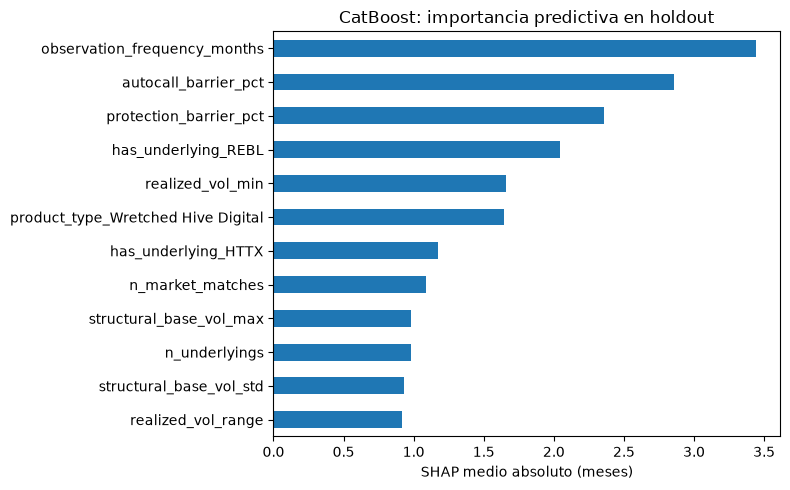

In [8]:
gam_feature_names = gam.named_steps['features'].get_feature_names_out()
gam_coefficients = pd.DataFrame({
    'term': gam_feature_names,
    'coefficient': gam.named_steps['regressor'].coef_,
})
gam_linear_effects = (
    gam_coefficients.loc[gam_coefficients['term'].str.startswith('linear__')]
    .assign(abs_coefficient=lambda x: x['coefficient'].abs())
    .sort_values('abs_coefficient', ascending=False)
)
gam_linear_effects.to_csv(REPORTS_DIR / 'gam_linear_effects.csv', index=False)
display(gam_linear_effects.head(15))

shap_values = catboost.get_feature_importance(
    type='ShapValues',
    data=Pool(X_test),
)
shap_importance = pd.DataFrame({
    'feature': feature_columns,
    'mean_abs_shap_months': np.abs(shap_values[:, :-1]).mean(axis=0),
}).sort_values('mean_abs_shap_months', ascending=False)
shap_importance.to_csv(REPORTS_DIR / 'catboost_shap_importance.csv', index=False)
display(shap_importance.head(15))

plot_data = shap_importance.head(12).sort_values('mean_abs_shap_months')
ax = plot_data.plot.barh(x='feature', y='mean_abs_shap_months', legend=False, figsize=(8, 5))
ax.set(xlabel='SHAP medio absoluto (meses)', ylabel='', title='CatBoost: importancia predictiva en holdout')
plt.tight_layout()
plt.show()

## Modelos guardados e inferencia reproducible

Los modelos se guardan en `models/`, separados por tipo de modelo. El informe `models/README.md` resume la comparación. La inferencia recibe una RFQ ya preprocesada mediante el mismo contrato de variables que genera `Preprocess_starwars.ipynb`.

In [9]:
feature_contract = {
    'target': TARGET,
    'feature_columns': feature_columns,
    'time_column': 'requested_date',
    'holdout_start': str(test_start.date()),
    'operational_horizon_days': 7,
    'primary_model': 'model.cbm',
    'unit': 'months',
}
with open(CATBOOST_DIR / 'feature_contract.json', 'w', encoding='utf-8') as stream:
    json.dump(feature_contract, stream, indent=2, ensure_ascii=False)

def predict_primary(features: pd.DataFrame, artifact_dir: Path = CATBOOST_DIR) -> pd.Series:
    """Predice duración para RFQs futuras ya preprocesadas y sin información futura."""
    with open(artifact_dir / 'feature_contract.json', encoding='utf-8') as stream:
        contract = json.load(stream)
    expected = contract['feature_columns']
    missing = sorted(set(expected) - set(features.columns))
    if missing:
        raise ValueError(f'Faltan variables requeridas: {missing}')
    X_new = features.loc[:, expected]
    if X_new.isna().any().any():
        raise ValueError('La inferencia no admite nulos en las variables del contrato.')
    model = CatBoostRegressor()
    model.load_model(str(artifact_dir / contract['primary_model']))
    return pd.Series(model.predict(X_new), index=features.index, name='predicted_avg_duration_months')

inference_smoke_test = predict_primary(test.head(3))
display(inference_smoke_test)
print('Artefactos generados:')
for path in sorted(MODELS_DIR.rglob('*')):
    if path.is_file():
        print(' -', path.relative_to(MODELS_DIR))

19    17.885605
33    47.884519
59    43.712104
Name: predicted_avg_duration_months, dtype: float64

Artefactos generados:
 - .gitkeep
 - README.md
 - baseline/seasonal_medians.csv
 - catboost/feature_contract.json
 - catboost/model.cbm
 - gam/model.joblib
 - reports/catboost_shap_importance.csv
 - reports/gam_linear_effects.csv
 - reports/holdout_metrics.csv


## Controles de fuga de información

- Se excluyen target, resultado de ejecución, identificador y fechas posteriores a la cotización.
- La volatilidad de mercado usada es la última disponible estrictamente antes de la RFQ.
- El baseline, el GAM y CatBoost se entrenan solo con el bloque pasado.
- El target solo existe para RFQs ejecutadas: esto es un posible sesgo de selección que debe declararse.

Los siguientes análisis —backtesting, curvas explicativas e ingeniería adicional— se harán en notebooks separados y solo después de entender y aprobar este flujo base.